In [17]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np
import matplotlib.pyplot as plt

In [25]:
# Load your pantry data
pantries = pd.read_csv("Pantry probs.csv")

In [ ]:

pantries_gdf = gpd.GeoDataFrame(pantries, geometry=gpd.points_from_xy(pantries.Long, pantries.Lat), crs='EPSG:4326')

# Convert to a projected coordinate system (for miles)
pantries_gdf = pantries_gdf.to_crs(epsg=32618)  # UTM zone for NY area

# Create a 6-mile buffer (~9656 meters)
pantries_gdf['buffer'] = pantries_gdf.buffer(9656)

# --- STEP 3. Convert to a projected coordinate system (for distance in meters) ---
# UTM Zone 18N covers Tompkins County area
gdf = pantries_gdf.to_crs(epsg=32618)

# --- STEP 4. Define parameters ---
radius_meters = 6 * 1609.34   # 6 miles in meters
decay_rate = 0.765            # 23.5% decrease per mile

def decay(distance_miles):
    return decay_rate ** distance_miles

# --- STEP 5. Create an expanded grid around all pantries for visualization ---
x_min, y_min, x_max, y_max = gdf.total_bounds

# Expand bounds by the 6-mile radius (in meters)
buffer = 6 * 1609.34
x_min -= buffer
x_max += buffer
y_min -= buffer
y_max += buffer

# Generate grid points
grid_x, grid_y = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300))

# Flatten to points
points = [Point(x, y) for x, y in zip(grid_x.flatten(), grid_y.flatten())]

# --- STEP 6. Compute probability field for ONE pantry as example ---
pantry_idx = 3  #! change this to visualize other pantries
pantry_point = gdf.geometry.iloc[pantry_idx]

# Compute distances in miles
distances = np.array([pantry_point.distance(p)/1609.34 for p in points])
probabilities = decay(distances)

# Clip to 6-mile radius
probabilities[distances > 6] = 0



   Pantry       Long        Lat
0       1  42.447582 -76.627995
1       2  42.418785 -76.518493
2       3  42.440839 -76.509117
3       4  42.440843 -76.507194
4       5  42.441182 -76.502153
5       6  42.441282 -76.500584
6       7  42.448983 -76.503488
7       8  42.433216 -76.457388


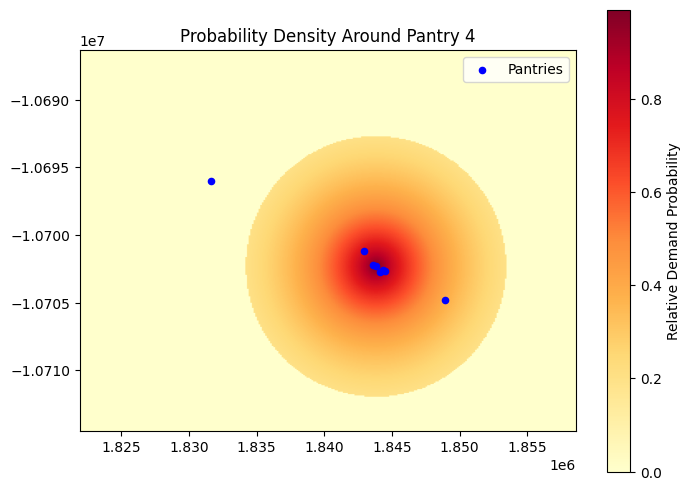

In [ ]:
# --- STEP 7. Visualize ---
plt.figure(figsize=(8, 6))
plt.imshow(
    probabilities.reshape(grid_x.shape),
    extent=[x_min, x_max, y_min, y_max],
    origin='lower',
    cmap='YlOrRd'
)
plt.colorbar(label='Relative Demand Probability')
plt.scatter(gdf.geometry.x, gdf.geometry.y, color='blue', s=20, label='Pantries')
plt.title(f"Probability Density Around Pantry {gdf['Pantry'].iloc[pantry_idx]}")
plt.legend()
plt.show()

In [22]:
def dist_pantry_prob(pantry):
    pantries_gdf = gpd.GeoDataFrame(pantries, geometry=gpd.points_from_xy(pantries.Long, pantries.Lat), crs='EPSG:4326')

    # Convert to a projected coordinate system (for miles)
    pantries_gdf = pantries_gdf.to_crs(epsg=32618)  # UTM zone for NY area

    # Create a 6-mile buffer (~9656 meters)
    pantries_gdf['buffer'] = pantries_gdf.buffer(9656)

    # --- STEP 3. Convert to a projected coordinate system (for distance in meters) ---
    # UTM Zone 18N covers Tompkins County area
    gdf = pantries_gdf.to_crs(epsg=32618)

    # --- STEP 4. Define parameters ---
    radius_meters = 6 * 1609.34   # 6 miles in meters
    decay_rate = 0.765            # 23.5% decrease per mile

    def decay(distance_miles):
        return decay_rate ** distance_miles

    # --- STEP 5. Create an expanded grid around all pantries for visualization ---
    x_min, y_min, x_max, y_max = gdf.total_bounds

    # Expand bounds by the 6-mile radius (in meters)
    buffer = 6 * 1609.34
    x_min -= buffer
    x_max += buffer
    y_min -= buffer
    y_max += buffer

    # Generate grid points
    grid_x, grid_y = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300))

    # Flatten to points
    points = [Point(x, y) for x, y in zip(grid_x.flatten(), grid_y.flatten())]

    # --- STEP 6. Compute probability field for ONE pantry as example ---
    pantry_point = gdf.geometry.iloc[pantry]

    # Compute distances in miles
    distances = np.array([pantry_point.distance(p)/1609.34 for p in points])
    probabilities = decay(distances)

    # Clip to 6-mile radius
    probabilities[distances > 6] = 0

    # --- STEP 7. Visualize ---
    plt.figure(figsize=(8, 6))
    plt.imshow(
        probabilities.reshape(grid_x.shape),
        extent=[x_min, x_max, y_min, y_max],
        origin='lower',
        cmap='YlOrRd'
    )
    plt.colorbar(label='Relative Demand Probability')
    plt.scatter(gdf.geometry.x, gdf.geometry.y, color='blue', s=20, label='Pantries')
    plt.title(f"Probability Density Around Pantry {gdf['Pantry'].iloc[pantry]}")
    plt.legend()
    plt.show()

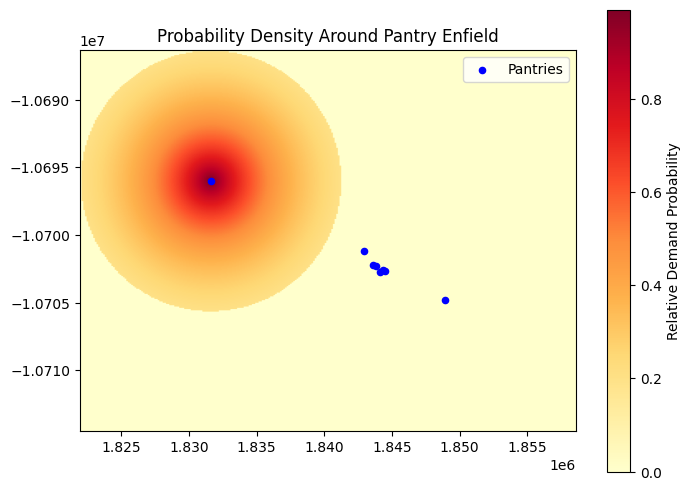

In [26]:
dist_pantry_prob(0)